# MWE: reconstructing an image from AMI-like data

An image fit in drpangloss is an ordinary call to `fit` whose model contains an `Image`. The pixels' log-brightnesses get flat priors from `drpangloss.imaging.image_priors`, and a regulariser supplies the prior information that the data cannot: here maximum entropy, which prefers images close to a flat default. The unresolved star stays an analytic `PointSource` at the origin, which also fixes the image's position, since the data are blind to shifts.

The data are simulated with `drpangloss.coverage.ami_grid_record`, which mimics AMIGO's representation of AMI: complex visibilities on a fine uv grid, of which only the mask's splodges carry information, compressed into orthonormal modes that keep 99% of the precision and are blind to the source's flux and position. The extended emission has only 3% of the star's flux. You should come away able to set up an image fit, compare it with the truth, and read its diagnostics.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from drpangloss.coverage import ami_grid_record
from drpangloss.fitting import fit
from drpangloss.imaging import (
    MaxEntropy,
    beam,
    diagnose,
    field_of_view,
    image_priors,
    nyquist_pixel_scale,
)
from drpangloss.likelihood import whitened_residuals
from drpangloss.models import GaussianDisk, Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model, plot_residual_map
from drpangloss.scenes import ring

template = OIData(ami_grid_record(wavelength_m=4.8e-6, rotation_deg=-6.9))
scale, flux = 10.0, 0.03
npix = round(field_of_view(template) / scale)  # 500 mas, or λ/B_min if smaller
truth_image = ring(
    npix,
    scale,
    80.0,
    12.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.5,
    asymmetry_pa_deg=90.0,
)
truth = System(
    star=PointSource(),
    env=Image.from_brightness(truth_image, scale, flux=flux),
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
print(f"{template.u.size} uv cells in the splodges, {data.vis.size} modes")
print(
    f"{npix}² pixels of {scale} mas (Nyquist: {nyquist_pixel_scale(data):.0f} mas), a {npix * scale:.0f} mas field"
)

412 uv cells in the splodges, 588 modes
50² pixels of 10.0 mas (Nyquist: 84 mas), a 500 mas field


## The fit

The fit starts from a blurred Gaussian with the right flux, a stand-in for a parametric fit. Maximum entropy has no least-squares form, so `fit` uses L-BFGS. The weight of 30 is where χ² per data point reaches one in the L-curve of the next MWE (the discrepancy principle).

In [2]:
start = System(
    star=PointSource(),
    env=Image.from_model(GaussianDisk(60.0), npix, scale, flux=flux),
)
regularisers = [MaxEntropy(30.0, path="env")]
result = fit(start, image_priors(start), data, regularisers)
info = result.info
print(
    f"{info['method']}: converged = {info['converged']} after {info['steps']} steps, chi2 per point {info['chi2_red']:.3f}"
)

lbfgs: converged = True after 270 steps, chi2 per point 0.997


## Truth, reconstruction and residual

With the information confined to the splodges and only 3% of the flux in the ring, the reconstruction is much coarser than the truth: it recovers a lopsided arc following the ring, brightest on its eastern side, with only a hint of the central hole. That is about what to expect, since the finest fringes are about 165 mas, comparable to the ring's 160 mas diameter. The shaded ellipse in the lower left of the reconstruction is the beam from `drpangloss.imaging.beam`, the FWHM of a Gaussian matched to the core of the data's dirty beam: roughly the size and shape of a resolution element. The right panel is the signed difference, reconstruction minus truth, on a symmetric scale; it has no uncertainty attached, so it is not a z-score. Red is flux the reconstruction adds and blue is flux it misses. All images are North up and East left.

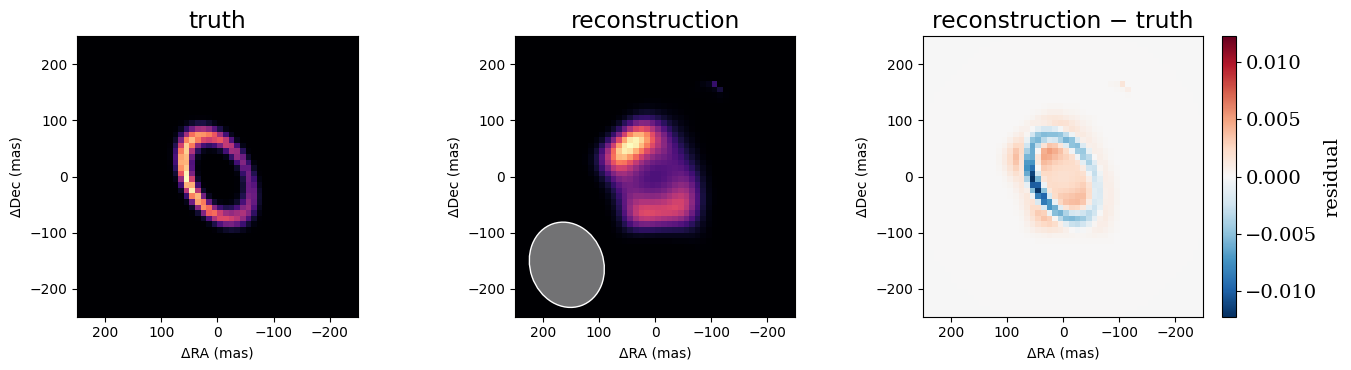

In [3]:
fov = npix * scale
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
plot_model(truth.env, fov_mas=fov, npix=npix, ax=axes[0], title="truth")
plot_model(
    result.model.env,
    fov_mas=fov,
    npix=npix,
    ax=axes[1],
    title="reconstruction",
    beam=beam(data),
)
difference = result.model.env.render(npix, fov) - truth.env.render(npix, fov)
plot_residual_map(
    difference, fov_mas=fov, ax=axes[2], title="reconstruction − truth"
)
plt.tight_layout()
plt.show()

## Residuals in the data

In the data, every mode has a known error, so here the residuals are z-scores, (model − data)/σ. They should look like unit-variance noise if the fit is good, and the histogram is compared with a standard normal curve.

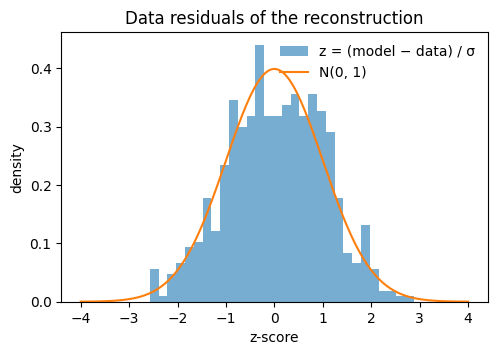

In [4]:
z = whitened_residuals(result.model, data)
x = jnp.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(z, bins=30, density=True, alpha=0.6, label="z = (model − data) / σ")
ax.plot(x, jnp.exp(-0.5 * x**2) / jnp.sqrt(2 * jnp.pi), label="N(0, 1)")
ax.set(
    xlabel="z-score",
    ylabel="density",
    title="Data residuals of the reconstruction",
)
ax.legend(frameon=False)
plt.show()

## Diagnostics

`diagnose` runs a set of checks on the fitted model: χ² per point, whether the pixels are fine enough, how much flux sits at the edge of the field, what fixes the position, whether the data constrain the orientation (the change in χ² when the image is rotated by 180°), and whether the model visibilities stay where projected phases are reliable. It warns only about actual problems.

In [5]:
print(diagnose(result.model, data, regularisers))

chi2_red         [0.997]
anchored         True
pixel_scale_mas  [10]
edge_flux        [1.36e-05]
centroid_mas     [[11.3, 5.7]]
flip_dchi2       444
phase_regime     [0]

No warnings.


## Summary

Reconstructing an image takes a `System` with an analytic star and an `Image`, flat priors from `image_priors`, one regulariser and a call to `fit`. On AMI-like data with realistic, splodge-limited information and a faint (3%) ring, maximum entropy recovers the ring's size, inclination, orientation and asymmetry, fits the data to the noise, and passes `diagnose`, while the residual map shows what it cannot recover: the ring's sharp edges. How strong to make the regulariser is the subject of the next MWE.